In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================================
# 1. 데이터 로드
# ============================================================
df = pd.concat([
    pd.read_csv("Final_seoraksan_part1_v2_sujin_260602.csv"),
    pd.read_csv("Final_seoraksan_part2_v2_sujin_260602.csv"),
    pd.read_csv("Final_seoraksan_part3_v2_sujin_260602.csv"),
], ignore_index=True)

print(f"총 격자점: {len(df):,}")

# ============================================================
# 2. landing_score 생성 (예측 대상 — 연속값)
# ------------------------------------------------------------
# 분류(0/1/2) 대신 연속 점수를 타겟으로 사용
# → slope_deg × tree_density 조합이 타겟에 1:1 매핑되는
#   누수 문제 해결 (RF가 보간을 학습해야 하므로 역산 불가)
#
# 가중치 근거:
#   slope_deg   0.55 — FAA-H-8083-21B, US Army FM 3-04.113, NATO STANAG 3619
#   tree_density 0.33 — US Army FM 3-04.113, 한국 산림청 헬기 운용 매뉴얼
#   tree_height  0.12 — US Army FM 3-04.113
# ============================================================
slope_score_map   = {0: 1.00, 1: 0.70, 2: 0.35, 3: 0.10, 4: 0.00}
density_score_map = {0: 1.00, 1: 0.85, 2: 0.21, 3: 0.00}
height_score_map  = {0: 1.00, 1: 0.61, 2: 0.31, 3: 0.31}

df['slope_score']   = df['slope_deg'].map(slope_score_map)
df['density_score'] = df['tree_density'].map(density_score_map)
df['height_score']  = df['tree_height'].map(height_score_map)

df['landing_score'] = (
    df['slope_score']   * 0.55 +
    df['density_score'] * 0.33 +
    df['height_score']  * 0.12
)

print(f"landing_score 범위: {df['landing_score'].min():.3f} ~ {df['landing_score'].max():.3f}")

# ============================================================
# 3. K-Means 5구역 분할
# ============================================================
coords_scaled = StandardScaler().fit_transform(df[['latitude', 'longitude']].values)
df['zone'] = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42).fit_predict(coords_scaled)

print("\n[K-Means 구역별 데이터 수]")
for z in range(5):
    sub = df[df['zone'] == z]
    print(f"  Zone {z}: {len(sub):>9,}개 | "
          f"lat {sub['latitude'].min():.4f}~{sub['latitude'].max():.4f} | "
          f"lon {sub['longitude'].min():.4f}~{sub['longitude'].max():.4f}")

# ============================================================
# 4. 버퍼존 생성 및 제거 (벡터 연산)
# ============================================================
print("\n버퍼존 계산 중...")

df['lat_idx'] = ((df['latitude']  - df['latitude'].min())  / 0.00015).round().astype(int)
df['lon_idx'] = ((df['longitude'] - df['longitude'].min()) / 0.00015).round().astype(int)

max_lat = df['lat_idx'].max() + 1
max_lon = df['lon_idx'].max() + 1
grid = np.full((max_lat, max_lon), -1, dtype=np.int8)
grid[df['lat_idx'].values, df['lon_idx'].values] = df['zone'].values

BUFFER_CELLS = 5
lat_idx   = df['lat_idx'].values
lon_idx   = df['lon_idx'].values
zone_vals = df['zone'].values
is_boundary = np.zeros(len(df), dtype=bool)

for di in range(-BUFFER_CELLS, BUFFER_CELLS + 1):
    for dj in range(-BUFFER_CELLS, BUFFER_CELLS + 1):
        if di == 0 and dj == 0:
            continue
        ni = np.clip(lat_idx + di, 0, max_lat - 1)
        nj = np.clip(lon_idx + dj, 0, max_lon - 1)
        neighbor_zone = grid[ni, nj]
        is_boundary |= (neighbor_zone != -1) & (neighbor_zone != zone_vals)

df['is_boundary'] = is_boundary
n_boundary = is_boundary.sum()
print(f"  경계 격자(버퍼존): {n_boundary:,}개 ({n_boundary/len(df)*100:.1f}%)")
print(f"  유효 격자(버퍼 제거 후): {(~is_boundary).sum():,}개")

# ============================================================
# 5. Train / Test 분리
# ------------------------------------------------------------
# Test: 위도 평균 최대 구역 (북쪽)
# ============================================================
TEST_ZONE = 1
zone_lat_mean = df.groupby('zone')['latitude'].mean()
print(f"\nTest 구역: Zone {TEST_ZONE} (위도 평균: {zone_lat_mean[TEST_ZONE]:.5f}°)")

valid_df = df[~df['is_boundary']].copy()
train_df = valid_df[valid_df['zone'] != TEST_ZONE].copy()
test_df  = valid_df[valid_df['zone'] == TEST_ZONE].copy()

# 피처: 원본 측정값만 사용 (grade/score 컬럼 제외 → 누수 방지)
FEATURES = ['slope_deg', 'tree_density', 'tree_height', 'elevation', 'land_type']

X_train = train_df[FEATURES]
y_train = train_df['landing_score']
X_test  = test_df[FEATURES]
y_test  = test_df['landing_score']

print(f"\n[최종 분할 결과]")
print(f"  버퍼 제거 전 전체:  {len(df):>9,}개")
print(f"  버퍼 제거 후 전체:  {len(valid_df):>9,}개  (-{n_boundary:,}개)")
print(f"  Train:              {len(X_train):>9,}개  ({len(X_train)/len(valid_df)*100:.1f}%)")
print(f"  Test:               {len(X_test):>9,}개  ({len(X_test)/len(valid_df)*100:.1f}%)")
print(f"  실질 비율:          {len(X_train)/len(X_test):.2f} : 1")

print(f"\n[landing_score 분포 비교 — 편향 체크]")
print(f"  Train 평균: {y_train.mean():.4f} | Test 평균: {y_test.mean():.4f}")
print(f"  Train 표준편차: {y_train.std():.4f} | Test 표준편차: {y_test.std():.4f}")

# ============================================================
# 6. Train / Test CSV 저장
# ============================================================
save_cols = FEATURES + ['latitude', 'longitude', 'zone', 'landing_score']

train_df[save_cols].to_csv("train_data_1.csv", index=False)
test_df[save_cols].to_csv("test_data_1.csv",  index=False)
print(f"\nTrain CSV 저장 완료: train_data.csv ({len(train_df):,}행)")
print(f"Test  CSV 저장 완료: test_data.csv  ({len(test_df):,}행)")

총 격자점: 1,715,270
landing_score 범위: 0.037 ~ 1.000

[K-Means 구역별 데이터 수]
  Zone 0:   284,173개 | lat 38.1142~38.2499 | lon 128.3025~128.4224
  Zone 1:   286,077개 | lat 38.0962~38.2499 | lon 128.2499~128.3567
  Zone 2:   405,385개 | lat 38.0001~38.1341 | lon 128.3676~128.4999
  Zone 3:   427,788개 | lat 38.0001~38.1180 | lon 128.2501~128.3817
  Zone 4:   311,847개 | lat 38.1154~38.2501 | lon 128.4102~128.4999

버퍼존 계산 중...
  경계 격자(버퍼존): 27,266개 (1.6%)
  유효 격자(버퍼 제거 후): 1,688,004개

Test 구역: Zone 1 (위도 평균: 38.16263°)

[최종 분할 결과]
  버퍼 제거 전 전체:  1,715,270개
  버퍼 제거 후 전체:  1,688,004개  (-27,266개)
  Train:              1,406,653개  (83.3%)
  Test:                 281,351개  (16.7%)
  실질 비율:          5.00 : 1

[landing_score 분포 비교 — 편향 체크]
  Train 평균: 0.3303 | Test 평균: 0.2901
  Train 표준편차: 0.2200 | Test 표준편차: 0.2058

Train CSV 저장 완료: train_data.csv (1,406,653행)
Test  CSV 저장 완료: test_data.csv  (281,351행)


RF 모델


학습 시작...
학습 완료

모델 성능 지표
  RMSE : 0.0010  (낮을수록 좋음)
  R²   : 1.0000  (1.0 최고, 0.8+ 우수)
  예측 범위: 0.037 ~ 1.000

[Feature Importance vs Designed Weights]
Feature            Model   Design
---------------------------------
slope_deg         0.7341     0.55
tree_density      0.2625     0.33
tree_height       0.0034     0.12
elevation         0.0000     0.00
land_type         0.0000     0.00


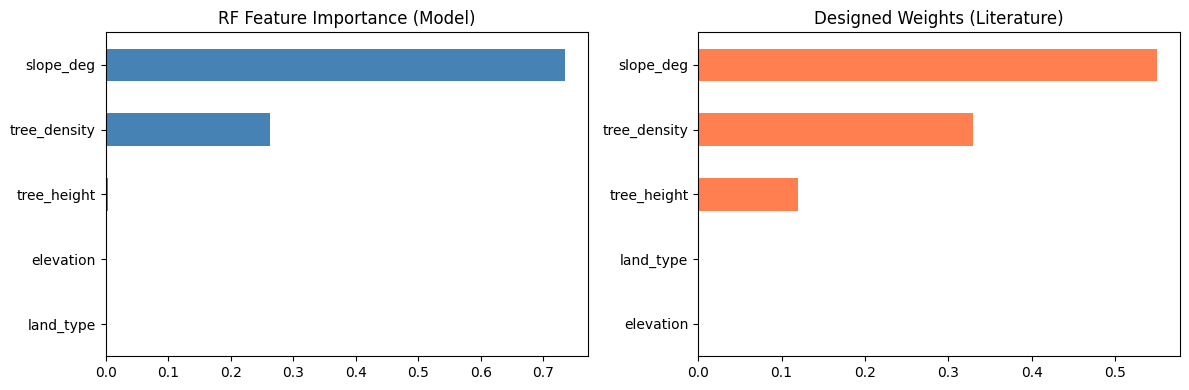


전체 격자 점수 예측 중...
예측 완료
[작전 개시] 구조 요청 지점 (위도: 38.1195, 경도: 128.4652) 주변 탐색 시작...

✨ 구조 지점 반경 500m 내 최선의 독립적 착륙 후보지 TOP 3 결과:

📍 [후보 1순위]
- 좌표: (위도: 38.11979, 경도: 128.46432)
- AI 예측 등급: ● 착륙 가능 (최적)
- 구조 지점과의 거리: 약 83.5 미터
- 상세 지형 정보: 고도 1659.0m | 경사등급 0 | land_type 0
------------------------------------------------------------

📍 [후보 2순위]
- 좌표: (위도: 38.11994, 경도: 128.46432)
- AI 예측 등급: ● 착륙 가능 (최적)
- 구조 지점과의 거리: 약 91.2 미터
- 상세 지형 정보: 고도 1648.8m | 경사등급 0 | land_type 0
------------------------------------------------------------

📍 [후보 3순위]
- 좌표: (위도: 38.11979, 경도: 128.46417)
- AI 예측 등급: ● 착륙 가능 (최적)
- 구조 지점과의 거리: 약 95.7 미터
- 상세 지형 정보: 고도 1657.6m | 경사등급 0 | land_type 0
------------------------------------------------------------


In [13]:
# ============================================================
# 7. RF 회귀 모델 학습
# ------------------------------------------------------------
# RandomForestRegressor: landing_score(연속값 0~1) 예측
# → 분류(0/1/2) 대신 회귀를 쓰는 이유:
#   피처 조합이 타겟에 1:1 매핑되는 누수를 차단하면서
#   착륙 적합도를 연속 점수로 출력해 Top N 정렬 가능
# ============================================================
# 학습 데이터 30만 샘플링 (전체 대비 22%, 패턴 학습엔 충분)
train_sample = train_df.sample(n=300_000, random_state=42)
X_train = train_sample[FEATURES]
y_train = train_sample['landing_score']

# Test는 전체 그대로 사용
X_test = test_df[FEATURES]
y_test = test_df['landing_score']

rf_model = RandomForestRegressor(
    n_estimators=100,    # 400 → 100 (시간 1/4, 성능 차이 미미)
    max_depth=8,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)

print("\n학습 시작...")
rf_model.fit(X_train, y_train)
print("학습 완료")

# ============================================================
# 8. 모델 평가
# ============================================================
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("모델 성능 지표")
print("="*50)
print(f"  RMSE : {rmse:.4f}  (낮을수록 좋음)")
print(f"  R²   : {r2:.4f}  (1.0 최고, 0.8+ 우수)")
print(f"  예측 범위: {y_pred.min():.3f} ~ {y_pred.max():.3f}")

# Feature Importance vs 설계 가중치 비교
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
design_w    = pd.Series({
    'slope_deg': 0.55, 'tree_density': 0.33,
    'tree_height': 0.12, 'elevation': 0.00, 'land_type': 0.00
})

print("\n[Feature Importance vs Designed Weights]")
print(f"{'Feature':<15} {'Model':>8} {'Design':>8}")
print("-"*33)
for f in FEATURES:
    print(f"{f:<15} {importances[f]:>8.4f} {design_w[f]:>8.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("RF Feature Importance (Model)")
design_w.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Designed Weights (Literature)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# ============================================================
# 9. 전체 격자 점수 예측
# ============================================================
print("\n전체 격자 점수 예측 중...")
valid_df['rf_pred_score'] = rf_model.predict(valid_df[FEATURES])
print("예측 완료")

# ============================================================
# 10. 신고 지점 기준 최적 후보지 Top 3 추천
# ============================================================
def haversine_m(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리(미터) — Haversine 공식"""
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def recommend_landing_sites(df, report_lat, report_lon,
                             radius_m=500, top_n=3):
    df = df.copy()
    df['distance_m'] = haversine_m(
        report_lat, report_lon,
        df['latitude'].values, df['longitude'].values
    )

    candidates = df[
        (df['distance_m'] <= radius_m) &
        (df['rf_pred_score'] > 0.0)
    ].copy()

    print(f"[작전 개시] 구조 요청 지점 (위도: {report_lat}, 경도: {report_lon}) 주변 탐색 시작...")
    print(f"\n✨ 구조 지점 반경 {radius_m}m 내 최선의 독립적 착륙 후보지 TOP {top_n} 결과:")

    if len(candidates) == 0:
        print("\n  ※ 반경 내 착륙 가능 후보가 없습니다.")
        print(f"     반경을 {radius_m + 500}m로 넓혀서 재탐색하세요.")
        return None

    candidates['combined_score'] = (
    candidates['rf_pred_score'] *
    (1 - candidates['distance_m'] / radius_m)
    )
    top = (candidates
        .sort_values('combined_score', ascending=False)
        .head(top_n)
        .reset_index(drop=True))

    def grade(score):
        if score >= 0.70:
            return "착륙 가능 (최적)"
        elif score >= 0.40:
            return "조건부 착륙 가능"
        else:
            return "착륙 주의"

    print("=" * 60)
    for i, row in top.iterrows():
        rank = i + 1
        print(f"\n📍 [후보 {rank}순위]")
        print(f"- 좌표: (위도: {row['latitude']:.5f}, 경도: {row['longitude']:.5f})")
        print(f"- AI 예측 등급: {grade(row['rf_pred_score'])}")
        print(f"- 구조 지점과의 거리: 약 {row['distance_m']:.1f} 미터")
        print(f"- 상세 지형 정보: 고도 {row['elevation']:.1f}m | "
              f"경사등급 {int(row['slope_deg'])} | "
              f"land_type {int(row['land_type'])}")
        print("-" * 60)

    return top

# 조난자 위치 입력 (실제 사용 시 아래 좌표 교체)
REPORT_LAT = 38.1195
REPORT_LON = 128.4652
RADIUS_M   = 500

result = recommend_landing_sites(
    valid_df,
    report_lat=REPORT_LAT,
    report_lon=REPORT_LON,
    radius_m=RADIUS_M,
    top_n=3
)